In [1]:
# To run this code, you'll need the OpenCV library. Let's install it first.
!pip install opencv-python matplotlib numpy

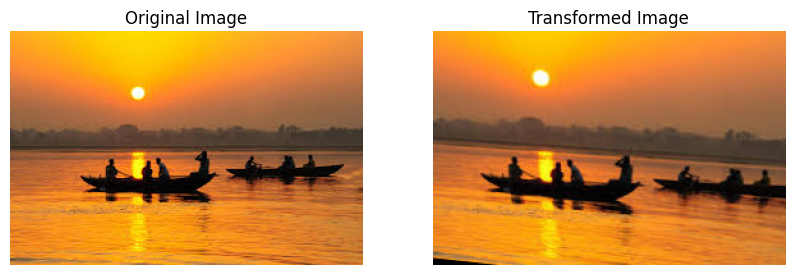

Original points:
[[ 55.  36.]
 [220.  36.]
 [220. 146.]
 [ 55. 146.]]

Destination points:
[[ 27.  18.]
 [248.  27.]
 [234. 164.]
 [ 41. 146.]]

Perspective Transformation Matrix:
[[ 1.23481949e+00  1.82267301e-01 -4.69957220e+01]
 [ 4.15343659e-02  1.37212601e+00 -3.33602779e+01]
 [-5.17879674e-04  1.28603319e-03  1.00000000e+00]]


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the nature image provided by the user
image = cv2.imread('/content/nature image.jpeg')

# Check if image was loaded successfully
if image is None:
    print("Error: Could not load image. Please check the file path and name.")
else:
    # Resize image if it's too large or too small for demonstration
    # For this example, let's resize it to a consistent width while maintaining aspect ratio
    (h, w) = image.shape[:2]
    # Let's target a width of 600 pixels if it's much larger, or keep original if smaller
    if w > 600:
        r = 600 / float(w)
        dim = (600, int(h * r))
        image = cv2.resize(image, dim, interpolation=cv2.INTER_AREA)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Define source points (corners of the area you want to transform)
    # These should be adjusted based on the new image content.
    # For demonstration, let's pick points that roughly represent a central rectangular area
    # You might need to adjust these manually based on your 'nature image.jpeg'
    # For a generic image, let's assume a central rectangular region.
    # Let's use 4 points within the image dimensions to create a general perspective effect
    h, w = image.shape[:2]
    source_points = np.float32([
        [int(w*0.2), int(h*0.2)],  # Top-left
        [int(w*0.8), int(h*0.2)],  # Top-right
        [int(w*0.8), int(h*0.8)],  # Bottom-right
        [int(w*0.2), int(h*0.8)]   # Bottom-left
    ])

    # Define destination points (where you want the source points to map to)
    # This will determine the perspective effect. Keep the same order as source_points.
    destination_points = np.float32([
        [int(w*0.1), int(h*0.1)],   # New top-left
        [int(w*0.9), int(h*0.15)],  # New top-right (shifted right and down slightly)
        [int(w*0.85), int(h*0.9)],  # New bottom-right (shifted further right and down)
        [int(w*0.15), int(h*0.8)]    # New bottom-left (shifted left and up slightly)
    ])

    # Get the perspective transformation matrix
    matrix = cv2.getPerspectiveTransform(source_points, destination_points)

    # Apply the perspective transformation
    transformed_image = cv2.warpPerspective(image, matrix, (image.shape[1], image.shape[0]))

    # Display the transformed image
    plt.subplot(1, 2, 2)
    plt.title('Transformed Image')
    plt.imshow(cv2.cvtColor(transformed_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

    print("Original points:")
    print(source_points)
    print("\nDestination points:")
    print(destination_points)
    print("\nPerspective Transformation Matrix:")
    print(matrix)
